SHAPE E INFO
<class 'pandas.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_key                 558 non-null    int64  
 1   nome_completo                558 non-null    str    
 2   eta                          558 non-null    int64  
 3   paese                        558 non-null    str    
 4   sesso                        558 non-null    str    
 5   tenure_giorni                558 non-null    int64  
 6   recency_giorni               558 non-null    int64  
 7   numero_ordini                558 non-null    int64  
 8   spesa_totale                 558 non-null    str    
 9   aov                          558 non-null    str    
 10  diversita_categorie          558 non-null    int64  
 11  quota_ordini_scontati        558 non-null    float64
 12  numero_ordini_annullati      558 non-null    int64  
 13  regolarita_acquist

C:\Users\Carlo Alberto\AppData\Local\Temp\ipykernel_3212\3738677116.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_churned', data=df, order=['No', 'Si'], palette=['#4C72B0', '#C44E52'])


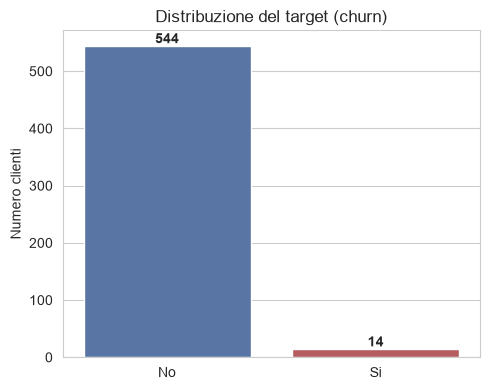

C:\Users\Carlo Alberto\AppData\Local\Temp\ipykernel_3212\3738677116.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_churned', y=col, data=df, order=['No', 'Si'], ax=ax,
C:\Users\Carlo Alberto\AppData\Local\Temp\ipykernel_3212\3738677116.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_churned', y=col, data=df, order=['No', 'Si'], ax=ax,
C:\Users\Carlo Alberto\AppData\Local\Temp\ipykernel_3212\3738677116.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_churned', y=col, data=df, order=['No', 'Si'],

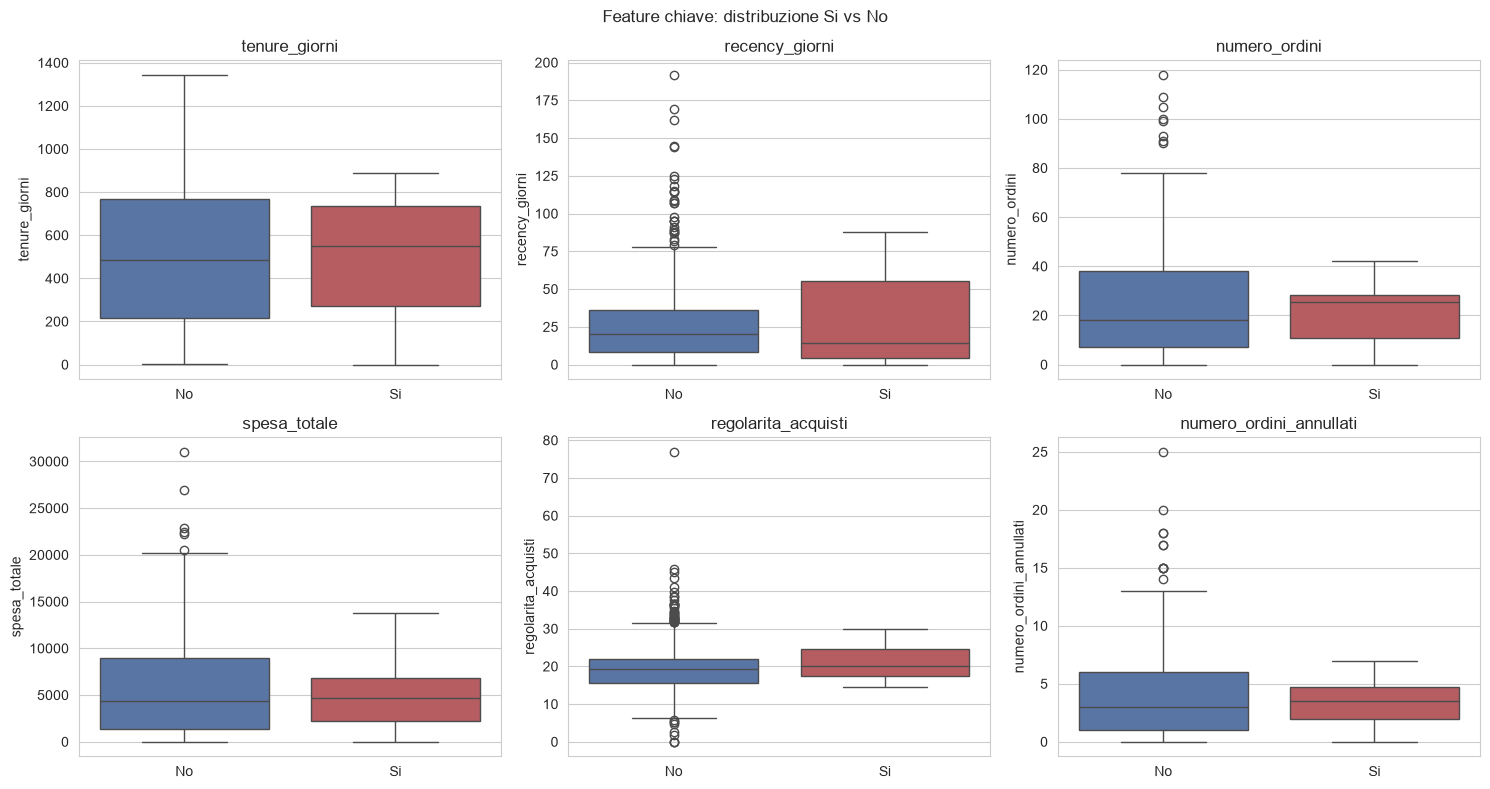

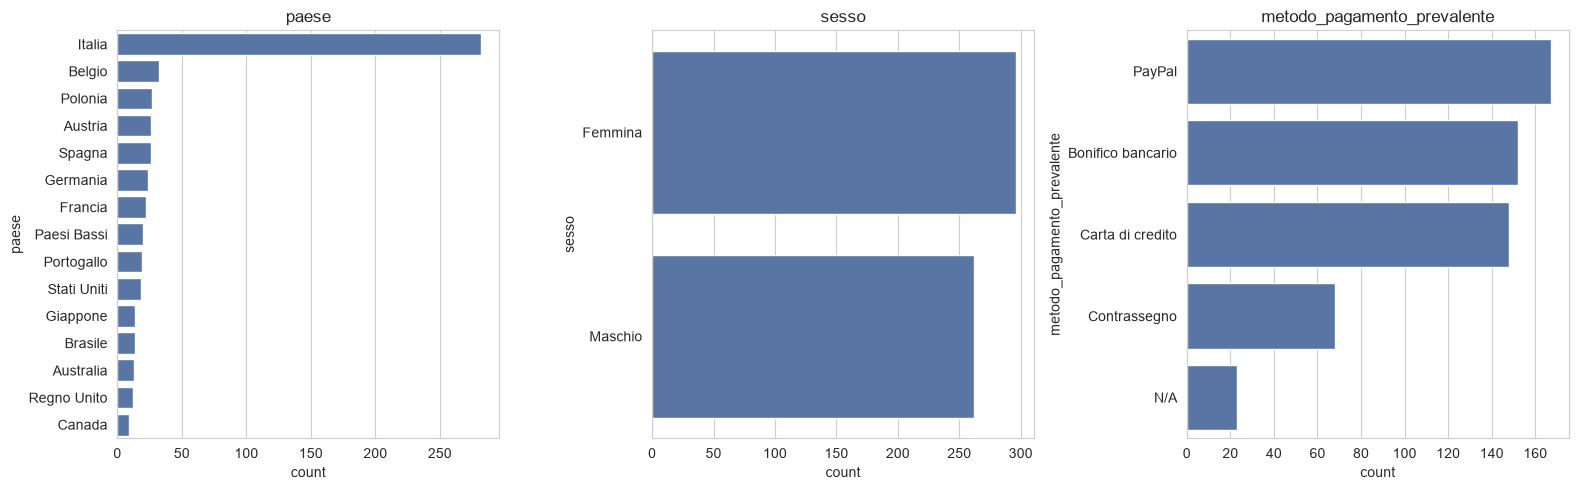

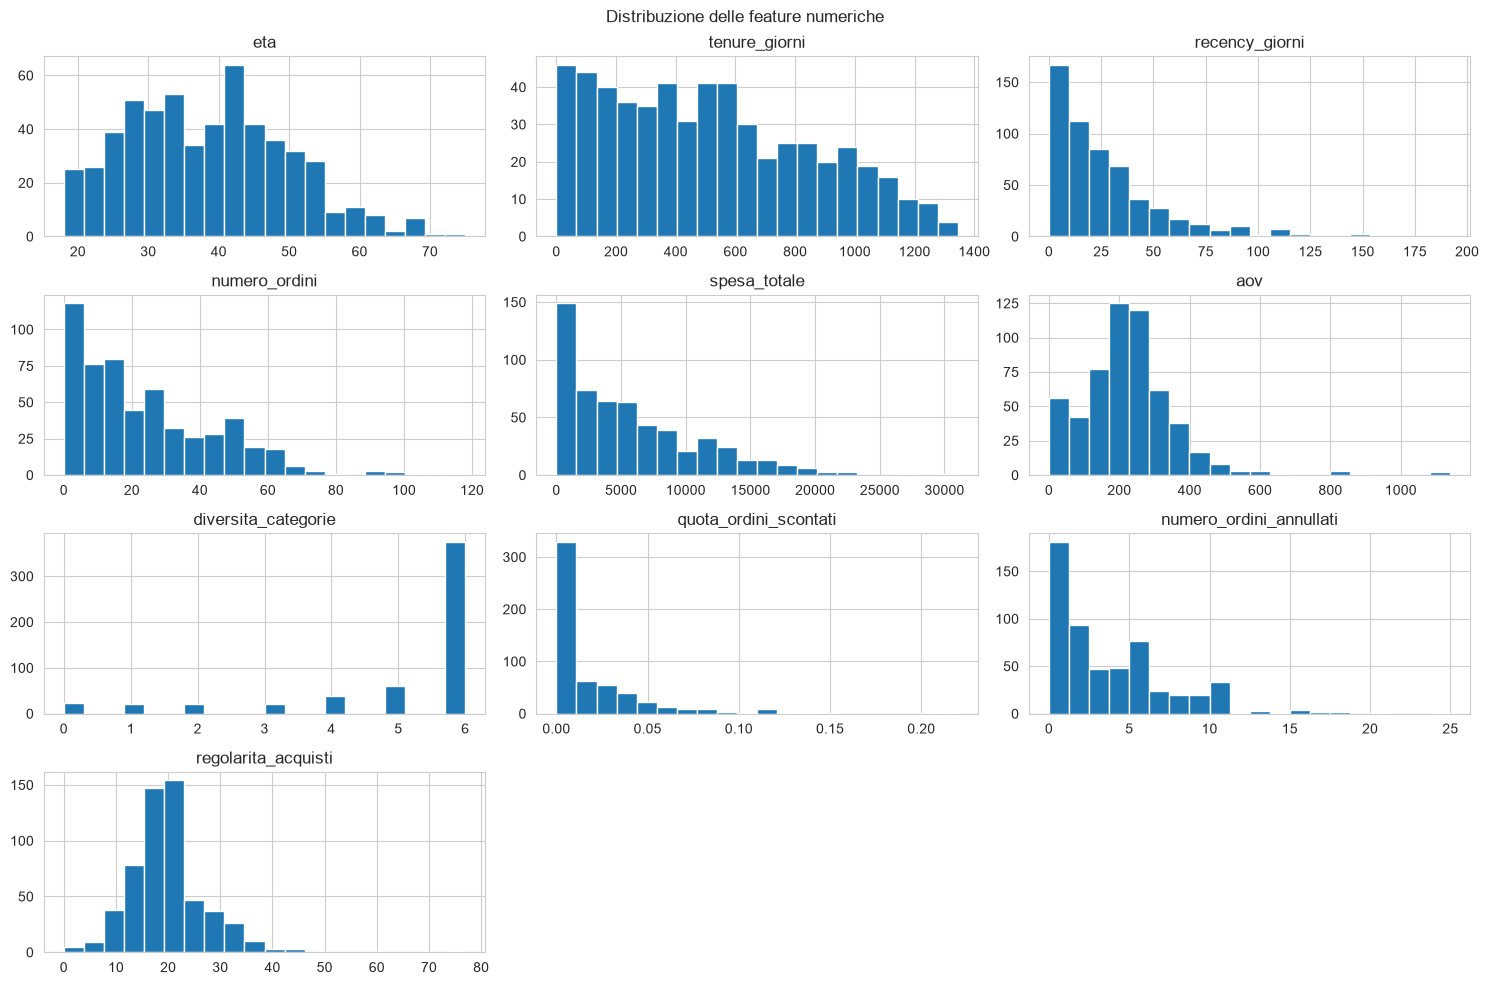

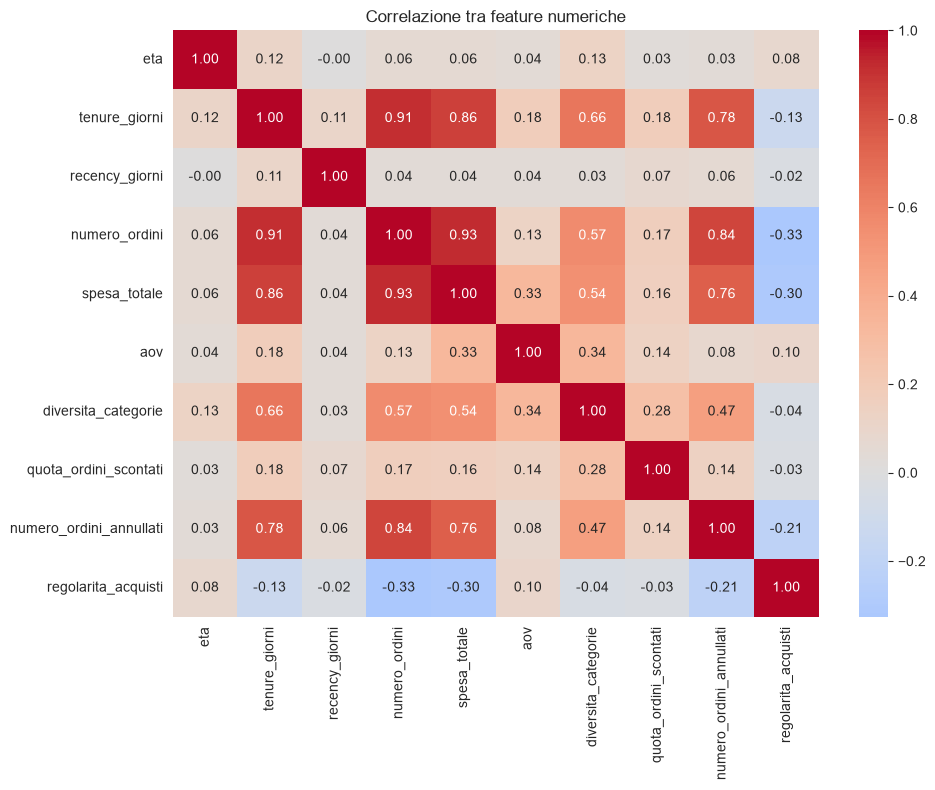

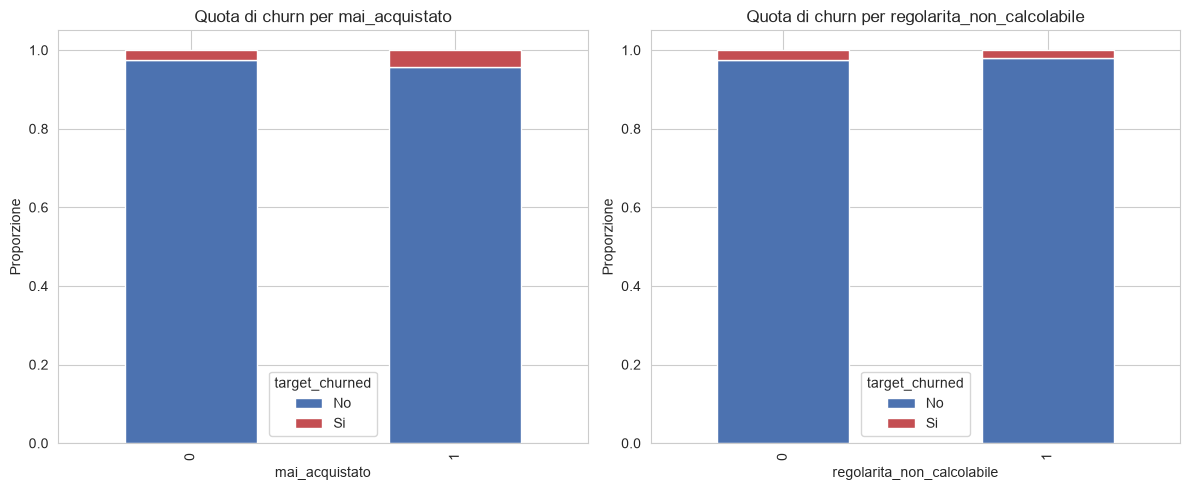


CHURN PER VARIABILI CATEGORICHE (conteggi grezzi)

--- zona ---
target_churned    No  Si
zona                    
Europa           204   4
Italia           273   9
Resto del mondo   67   1

--- sesso ---
target_churned   No  Si
sesso                  
Femmina         290   6
Maschio         254   8

--- metodo_pagamento_prevalente ---
target_churned                No  Si
metodo_pagamento_prevalente         
Bonifico bancario            151   1
Carta di credito             142   6
Contrassegno                  65   3
N/A                           22   1
PayPal                       164   3


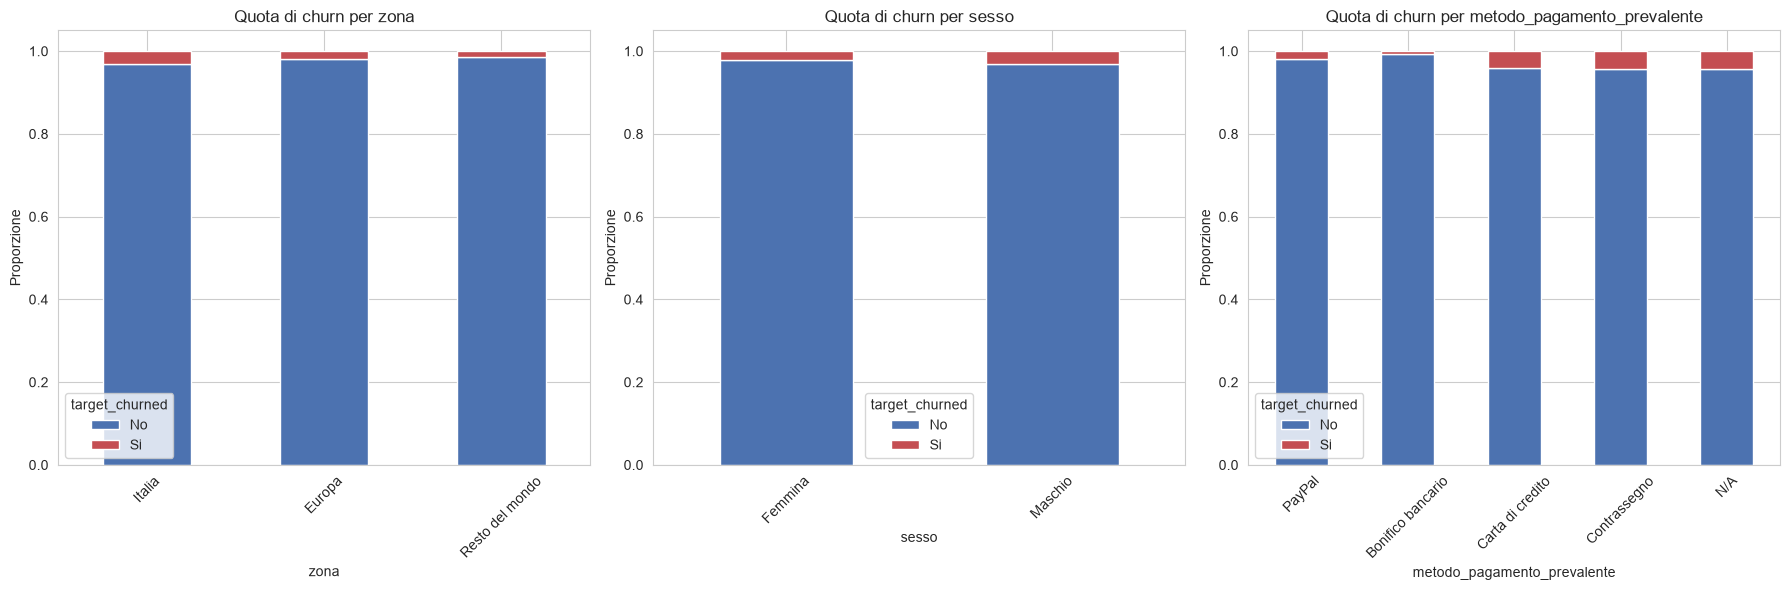


Grafici salvati nella cartella: c:\Users\Carlo Alberto\Downloads\E-Commerce\Viste_ML\Churn\grafici_eda_churn


In [11]:
"""
EDA - gold.vw_churn_training

"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 140)

# ---------------------------------------------------------------
# 1. CARICAMENTO
# ---------------------------------------------------------------
# keep_default_na=False: la vista scrive esplicitamente 'N/A' come placeholder
# per metodo_pagamento_prevalente (clienti mai_acquistato=1). Senza questo
# argomento, pandas interpreta 'N/A' testuale come NaN vero, perdendo il segnale.
df = pd.read_csv('Churn.csv', sep=';', encoding='utf-8-sig', keep_default_na=False)
print("="*60)
print("SHAPE E INFO")
print("="*60)
df.info()
print(df.shape)

# Conversione colonne con virgola decimale (export SSMS)
colonne_da_correggere = [
    "spesa_totale", "regolarita_acquisti",
    "aov"
]
for col in colonne_da_correggere:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="raise"
    )

print("\n" + "=" * 60)
print("TIPI DOPO LA CORREZIONE")
print("=" * 60)
df[colonne_da_correggere].info()

# ---------------------------------------------------------------
# 2. NULL RESIDUI
# ---------------------------------------------------------------
print("\n" + "="*60)
print("NULL PER COLONNA")
print("="*60)
print(df.isnull().sum())

# ---------------------------------------------------------------
# 3. DISTRIBUZIONE TARGET
# ---------------------------------------------------------------
print("\n" + "="*60)
print("DISTRIBUZIONE TARGET")
print("="*60)
print(df['target_churned'].value_counts())
print(df['target_churned'].value_counts(normalize=True).round(3))

# ---------------------------------------------------------------
# 4. CARDINALITA' CATEGORICHE
# ---------------------------------------------------------------
print("\n" + "="*60)
print("CARDINALITA' CATEGORICHE")
print("="*60)
for col in ['paese', 'sesso', 'metodo_pagamento_prevalente']:
    print(f"\n--- {col} ({df[col].nunique()} valori distinti) ---")
    print(df[col].value_counts())

# ---------------------------------------------------------------
# 5. STATISTICHE NUMERICHE
# ---------------------------------------------------------------
num_cols = ['eta', 'tenure_giorni', 'recency_giorni', 'numero_ordini', 'spesa_totale',
            'aov', 'diversita_categorie', 'quota_ordini_scontati',
            'numero_ordini_annullati', 'regolarita_acquisti']

print("\n" + "="*60)
print("DESCRIBE NUMERICHE")
print("="*60)
print(df[num_cols].describe().T)

print("\n" + "="*60)
print("SKEWNESS (indicatore di distribuzioni fortemente asimmetriche)")
print("="*60)
print(df[num_cols].skew().sort_values(ascending=False))

# ---------------------------------------------------------------
# 6. FLAG DI QUALITA' DATO
# ---------------------------------------------------------------
print("\n" + "="*60)
print("FLAG DI QUALITA' DATO")
print("="*60)
print("regolarita_non_calcolabile:\n", df['regolarita_non_calcolabile'].value_counts())
print("\nmai_acquistato:\n", df['mai_acquistato'].value_counts())

print("\nTarget vs mai_acquistato:")
print(pd.crosstab(df['mai_acquistato'], df['target_churned']))

print("\nTarget vs regolarita_non_calcolabile:")
print(pd.crosstab(df['regolarita_non_calcolabile'], df['target_churned']))

# ---------------------------------------------------------------
# 7. DUPLICATI
# ---------------------------------------------------------------
print("\n" + "="*60)
print("DUPLICATI")
print("="*60)
print("Righe duplicate esatte:", df.duplicated().sum())
print("customer_key duplicati:", df['customer_key'].duplicated().sum())

# ---------------------------------------------------------------
# 8. APPROFONDIMENTO SUI 14 CLIENTI "Si" (per decidere come gestire lo sbilanciamento)
# ---------------------------------------------------------------
print("\n" + "="*60)
print("PROFILO DEI CLIENTI CHURN ('Si') vs RESTO")
print("="*60)
churn_si = df[df['target_churned'] == 'Si']
churn_no = df[df['target_churned'] == 'No']

print(f"\nNumero clienti 'Si': {len(churn_si)}")
print("\nDettaglio riga per riga dei clienti churn:")
print(churn_si[['customer_key', 'nome_completo', 'eta', 'paese', 'tenure_giorni',
                 'recency_giorni', 'numero_ordini', 'spesa_totale',
                 'mai_acquistato', 'regolarita_non_calcolabile']].to_string())

print("\nConfronto medie: Si vs No")
comparison = pd.DataFrame({
    'media_Si': churn_si[num_cols].mean(),
    'media_No': churn_no[num_cols].mean()
})
print(comparison)

print("\nQuanti dei 14 'Si' sono anche mai_acquistato=1?")
print(churn_si['mai_acquistato'].value_counts())

# ---------------------------------------------------------------
# 9. GRAFICI
# ---------------------------------------------------------------
import os

# Mappatura paese -> zona (stessa logica usata nel clustering: Italia / Europa / Resto del mondo)
zona_map = {
    'Italia': 'Italia',
    'Belgio': 'Europa', 'Polonia': 'Europa', 'Austria': 'Europa', 'Spagna': 'Europa',
    'Germania': 'Europa', 'Francia': 'Europa', 'Paesi Bassi': 'Europa',
    'Portogallo': 'Europa', 'Regno Unito': 'Europa',
    'Stati Uniti': 'Resto del mondo', 'Giappone': 'Resto del mondo',
    'Brasile': 'Resto del mondo', 'Australia': 'Resto del mondo', 'Canada': 'Resto del mondo',
}
df['zona'] = df['paese'].map(zona_map)
if df['zona'].isnull().any():
    print("\nATTENZIONE: paesi non mappati in zona_map:", df.loc[df['zona'].isnull(), 'paese'].unique())

# Cartella dove salvare i grafici (creata se non esiste)
output_dir = "grafici_eda_churn"
os.makedirs(output_dir, exist_ok=True)

sns.set_style("whitegrid")

# 9.1 Distribuzione del target — il grafico piu' importante:
# rende immediatamente visibile quanto e' estremo lo sbilanciamento
plt.figure(figsize=(5, 4))
sns.countplot(x='target_churned', data=df, order=['No', 'Si'], palette=['#4C72B0', '#C44E52'])
plt.title("Distribuzione del target (churn)")
plt.xlabel("")
plt.ylabel("Numero clienti")
for i, v in enumerate(df['target_churned'].value_counts()[['No', 'Si']]):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "01_distribuzione_target.png"), dpi=150)
plt.show()

# 9.2 Boxplot delle feature numeriche chiave, Si vs No
# Il boxplot invece della sola media: con 14 casi, un outlier da solo
# potrebbe spiegare la differenza — il boxplot lo rende visibile.
feature_chiave = ['tenure_giorni', 'recency_giorni', 'numero_ordini',
                   'spesa_totale', 'regolarita_acquisti', 'numero_ordini_annullati']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), feature_chiave):
    sns.boxplot(x='target_churned', y=col, data=df, order=['No', 'Si'], ax=ax,
                palette=['#4C72B0', '#C44E52'])
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Feature chiave: distribuzione Si vs No")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "02_boxplot_feature_chiave.png"), dpi=150)
plt.show()

# 9.3 Cardinalita' delle categoriche
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['paese', 'sesso', 'metodo_pagamento_prevalente']):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "03_cardinalita_categoriche.png"), dpi=150)
plt.show()

# 9.4 Istogrammi delle numeriche, per verificare visivamente la skewness
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Distribuzione delle feature numeriche")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "04_istogrammi_numeriche.png"), dpi=150)
plt.show()

# 9.5 Heatmap di correlazione tra le numeriche
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlazione tra feature numeriche")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "05_heatmap_correlazione.png"), dpi=150)
plt.show()

# 9.6 mai_acquistato e regolarita_non_calcolabile vs target (in proporzione, non conteggio grezzo)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['mai_acquistato', 'regolarita_non_calcolabile']):
    ct = pd.crosstab(df[col], df['target_churned'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'])
    ax.set_title(f"Quota di churn per {col}")
    ax.set_ylabel("Proporzione")
    ax.legend(title='target_churned')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "06_quota_churn_per_flag_qualita.png"), dpi=150)
plt.show()

# 9.7 Quota di churn per variabili categoriche (zona, sesso, metodo di pagamento)
# Con soli 14 "Si" totali, le proporzioni da sole possono ingannare se un gruppo
# ha pochissimi clienti: stampo prima i conteggi grezzi, poi il grafico.
categoriche_churn = ['zona', 'sesso', 'metodo_pagamento_prevalente']

print("\n" + "="*60)
print("CHURN PER VARIABILI CATEGORICHE (conteggi grezzi)")
print("="*60)
for col in categoriche_churn:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df[col], df['target_churned']))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, categoriche_churn):
    ct = pd.crosstab(df[col], df['target_churned'], normalize='index')
    ct = ct.reindex(df[col].value_counts().index)  # ordina per numerosita' del gruppo
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'])
    ax.set_title(f"Quota di churn per {col}")
    ax.set_ylabel("Proporzione")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='target_churned')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "07_quota_churn_per_categoriche.png"), dpi=150)
plt.show()

print(f"\nGrafici salvati nella cartella: {os.path.abspath(output_dir)}")

MATRICE X
(558, 12)
eta                             int64
tenure_giorni                   int64
recency_giorni                  int64
numero_ordini                   int64
spesa_totale                  float64
aov                           float64
diversita_categorie             int64
quota_ordini_scontati         float64
numero_ordini_annullati         int64
regolarita_acquisti           float64
regolarita_non_calcolabile      int64
mai_acquistato                  int64
dtype: object

TARGET Y (dopo mapping 0/1)
target_churned
0    544
1     14
Name: count, dtype: int64

VERIFICA SPLIT (fondamentale con soli 14 casi 'Si' totali)
Train: 446 righe — Si: 11, No: 435
Test:  112 righe — Si: 3, No: 109

Proporzioni Si/No (devono essere simili train vs test):
Train: {0: 0.975, 1: 0.025}
Test:  {0: 0.973, 1: 0.027}

CLASS WEIGHT (RandomForest)
{np.int64(0): np.float64(0.5126436781609195), np.int64(1): np.float64(20.272727272727273)}

SCALE_POS_WEIGHT (XGBoost)
39.55
MIGLIORI IPERPARAMETRI TRO

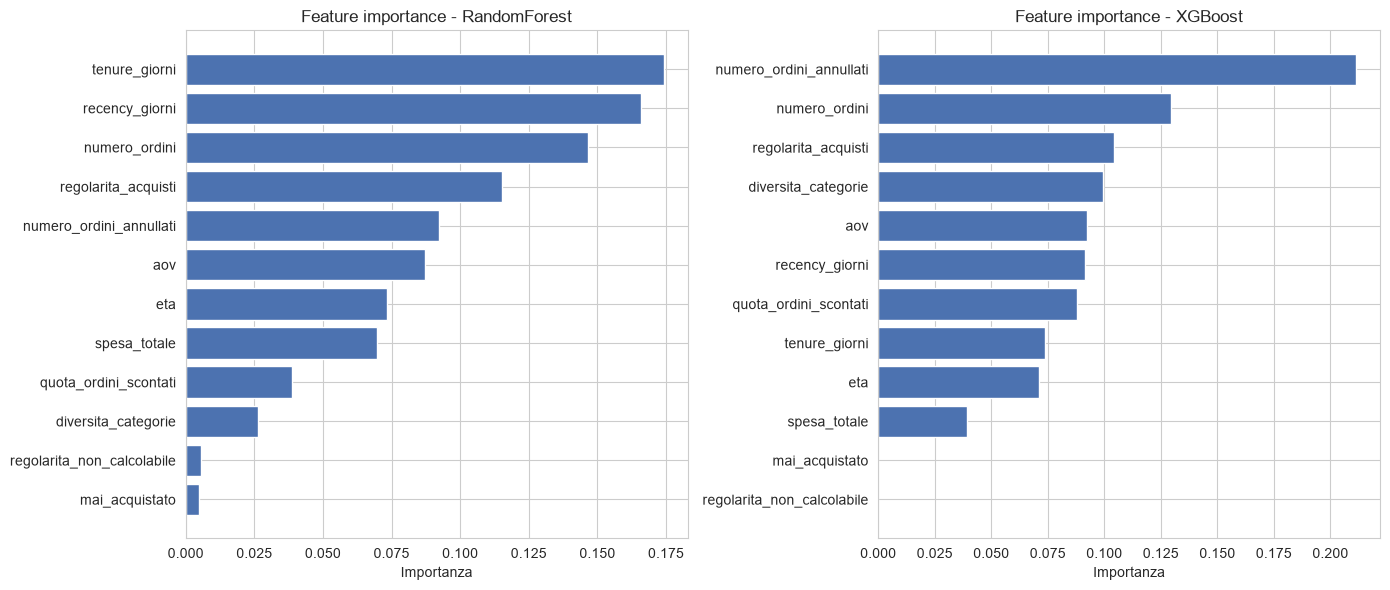

In [12]:
"""
Preparazione dati - Classificazione Churn

"""

import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier

pd.set_option('display.width', 140)

# ---------------------------------------------------------------
# 1. DEFINIZIONE FEATURE (X) E TARGET (y)
# ---------------------------------------------------------------
# Escluse dalla matrice:
# - customer_key, nome_completo: identificativi, non feature
# - paese, sesso, metodo_pagamento_prevalente: nessuna relazione visibile col
#   target nell'EDA; con soli 14 casi positivi, tenerle rischia overfitting
#   su correlazioni spurie invece di segnale reale
feature_cols = [
    'eta', 'tenure_giorni', 'recency_giorni', 'numero_ordini', 'spesa_totale',
    'aov', 'diversita_categorie', 'quota_ordini_scontati', 'numero_ordini_annullati',
    'regolarita_acquisti', 'regolarita_non_calcolabile', 'mai_acquistato'
]

X = df[feature_cols].copy()

# Target: da testo 'Si'/'No' a 0/1 (richiesto dagli algoritmi)
y = df['target_churned'].map({'No': 0, 'Si': 1})

print("="*60)
print("MATRICE X")
print("="*60)
print(X.shape)
print(X.dtypes)

print("\n" + "="*60)
print("TARGET Y (dopo mapping 0/1)")
print("="*60)
print(y.value_counts())

# ---------------------------------------------------------------
# 2. SPLIT TRAIN/TEST (stratificato, obbligatorio con classi sbilanciate)
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\n" + "="*60)
print("VERIFICA SPLIT (fondamentale con soli 14 casi 'Si' totali)")
print("="*60)
print(f"Train: {X_train.shape[0]} righe — Si: {y_train.sum()}, No: {(y_train==0).sum()}")
print(f"Test:  {X_test.shape[0]} righe — Si: {y_test.sum()}, No: {(y_test==0).sum()}")
print("\nProporzioni Si/No (devono essere simili train vs test):")
print("Train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test: ", y_test.value_counts(normalize=True).round(3).to_dict())

# ---------------------------------------------------------------
# 3. CALCOLO CLASS WEIGHT (per RandomForest e XGBoost)
# ---------------------------------------------------------------
# RandomForest: usa class_weight come dizionario {classe: peso}
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights_array))

print("\n" + "="*60)
print("CLASS WEIGHT (RandomForest)")
print("="*60)
print(class_weight_dict)

# XGBoost: usa scale_pos_weight come singolo numero = negativi/positivi nel train
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("\n" + "="*60)
print("SCALE_POS_WEIGHT (XGBoost)")
print("="*60)
print(round(scale_pos_weight, 2))


# ---------------------------------------------------------------
# 4. CROSS-VALIDATION RIDOTTA
# ---------------------------------------------------------------
# Con soli ~11 "Si" nel train, cv=5 lascerebbe 2-3 casi per fold: instabile.
# cv=3 e' il compromesso minimo per avere almeno qualche caso positivo per fold.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 
# ---------------------------------------------------------------
# 5. RANDOM FOREST
# ---------------------------------------------------------------
rf = RandomForestClassifier(class_weight=class_weight_dict, random_state=42)
 
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
 
rf_random = RandomizedSearchCV(
    rf, rf_params,
    n_iter=20, cv=cv_strategy,
    scoring="f1",          # non "accuracy": qui sarebbe fuorviante (vedi EDA)
    n_jobs=-1, random_state=42
)
rf_random.fit(X_train, y_train)
 
# ---------------------------------------------------------------
# 6. XGBOOST
# ---------------------------------------------------------------
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
 
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
 
xgb_random = RandomizedSearchCV(
    xgb, xgb_params,
    n_iter=20, cv=cv_strategy,
    scoring="f1",
    n_jobs=-1, random_state=42
)
xgb_random.fit(X_train, y_train)
 
# ---------------------------------------------------------------
# 7. CONFRONTO SUL TEST SET
# ---------------------------------------------------------------
models = {
    "RandomForest": rf_random.best_estimator_,
    "XGBoost": xgb_random.best_estimator_,
}
 
print("="*70)
print("MIGLIORI IPERPARAMETRI TROVATI")
print("="*70)
print("RandomForest:", rf_random.best_params_)
print("XGBoost:     ", xgb_random.best_params_)
 
for name, model in models.items():
    y_pred = model.predict(X_test)
 
    print("\n" + "="*70)
    print(f"{name} — Risultati sul test set (112 clienti, di cui 3 'Si')")
    print("="*70)
 
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=['No', 'Si'], zero_division=0))
 
    print("Matrice di confusione:")
    print("           Predetto No  Predetto Si")
    cm = confusion_matrix(y_test, y_pred)
    print(f"Reale No       {cm[0,0]:>6}       {cm[0,1]:>6}")
    print(f"Reale Si       {cm[1,0]:>6}       {cm[1,1]:>6}")
 
    print(f"\nF1-score (classe 'Si'): {f1_score(y_test, y_pred, zero_division=0):.3f}")
 
# ---------------------------------------------------------------
# 8. FEATURE IMPORTANCE (per capire cosa ha pesato di piu' su ciascun modello)
# ---------------------------------------------------------------
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)
for name, model in models.items():
    print(f"\n--- {name} ---")
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    print(importances.sort_values(ascending=False))

# ---------------------------------------------------------------
# 9. GRAFICO FEATURE IMPORTANCE
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    ax.barh(importances.index, importances.values, color="#4C72B0")
    ax.set_title(f"Feature importance - {name}")
    ax.set_xlabel("Importanza")

plt.tight_layout()
plt.savefig("grafici_eda_churn/08_feature_importance.png", dpi=150)
plt.show()